# Week 7 (Part 1) — Transformers: Encoders, Decoders, and Attention

**CS F407 Artificial Intelligence · Lab 7** · Lab material: [`Transformer.pdf`](../lab-question/Transformer.pdf), [`AI_lab_transformers.ipynb`](../lab-question/AI_lab_transformers.ipynb)

This notebook covers the lecture notes and the three hands-on tasks:
- **The Transformer and its three families:** encoder-decoder, encoder-only, decoder-only.
- **The six concepts the notes list,** implemented from scratch in NumPy and checked against PyTorch: attention, self-attention, cross-attention, multi-head attention, positional encoding, masked attention.
- **The same mechanisms inside real models:** BERT, GPT-2 and T5.
- **Hands-on 1:** machine translation (encoder-decoder).
- **Hands-on 2:** sentiment analysis, plus semantic search and masked-word prediction (encoder-only).
- **Hands-on 3:** GPT-style generation (decoder-only).

The model outputs were produced by running the lab's models on an Apple-silicon Mac (MPS) with torch 2.14 and transformers 5.17, and are loaded from [`data/transformers_results.json`](data/transformers_results.json). The concept demonstrations run here directly. The second part of the lab, running GPT-type models locally with Ollama and comparing them with GPT and Claude, is in [`Ollama_LLM_Comparison.ipynb`](Ollama_LLM_Comparison.ipynb).

In [1]:
import json
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

OUT = pathlib.Path("outputs")
OUT.mkdir(exist_ok=True)
R = json.loads(pathlib.Path("data/transformers_results.json").read_text())
S = R["sections"]
pd.set_option("display.max_colwidth", 200)
print("model outputs from:", R["environment"])
print("sections:", [k for k in S])

model outputs from: {'python': '3.11.11', 'platform': 'macOS-27.0-arm64-arm-64bit', 'torch': '2.14.0', 'transformers': '5.17.0', 'device': 'mps', 'cuda': None}
sections: ['translation_bert2bert', 'translation_t5', 'translation_hinglish', 'cross_attention', 'sentiment', 'semantic_search', 'fill_mask', 'generation', 'bert_attention', 'architecture']


## 1. What the Transformer was introduced for, and its three families

**What was it initially introduced for?** The Transformer ("Attention Is All You Need", Vaswani et al., 2017) was introduced for **machine translation**. More generally, it was built for **sequence-to-sequence** tasks: reading one sequence (English) and producing another (French or German). It was an **encoder-decoder**:
- the **encoder** reads the whole source sentence and builds a contextual representation of every source token;
- the **decoder** generates the target one token at a time, attending both to what it has generated so far and to the encoder's representation.

Later models kept only one half:

| Family | Keeps | Attention | Trained to | Typical uses (from the notes) | Models used here |
|---|---|---|---|---|---|
| **Encoder-decoder** | both | bidirectional in the encoder, causal in the decoder, plus cross-attention | map an input sequence to an output sequence | translation, summarisation | bert2bert, T5-base, Flan-T5 (Hinglish) |
| **Encoder-only** | encoder | bidirectional self-attention | predict masked words (BERT), or produce embeddings | **understanding and representing** text: semantic search, document retrieval, clustering, classification | BERT-base, DistilBERT, MiniLM |
| **Decoder-only** | decoder, without cross-attention | causal (masked) self-attention | predict the next token | **generation**: text, chatbots, code, question answering, summarisation, writing help | GPT-2 (and every Ollama/GPT/Claude model in Part 2) |

The models used in the lab, as recorded by the helper script:

In [2]:
arch = pd.DataFrame(S["architecture"]["models"])
arch["layers"] = arch.apply(lambda r: f"{int(r.encoder_layers)} enc + {int(r.decoder_layers)} dec" if r.kind == "encoder-decoder"
                            else f"{int(r.layers)}", axis=1)
arch["parameters (M)"] = (arch.parameters / 1e6).round(1)
arch["model"] = arch.model.str.split("/").str[-1]
table = arch[["model", "kind", "parameters (M)", "layers", "attention_heads", "hidden_size", "vocab_size", "max_positions"]]
table.sort_values(["kind", "parameters (M)"])

,model,kind,parameters (M),layers,attention_heads,hidden_size,vocab_size,max_positions
4,gpt2,decoder-only,124.4,12,12,768,50257,1024
1,t5-base,encoder-decoder,222.9,12 enc + 12 dec,12,768,32128,512
6,English2Hinglish-Flan-T5-Base,encoder-decoder,247.6,12 enc + 12 dec,12,768,32128,512
0,bert2bert_L-24_wmt_en_de,encoder-decoder,771.9,24 enc + 24 dec,16,1024,31950,512
3,all-MiniLM-L6-v2,encoder-only,22.7,6,12,384,30522,512
2,distilbert-base-uncased-finetuned-sst-2-english,encoder-only,67.0,6,12,768,30522,512
5,bert-base-uncased,encoder-only,109.5,12,12,768,30522,512


**What the numbers show:**
- **The scale is small.** Even the largest model here, bert2bert, has 772M parameters: 24 encoder plus 24 decoder layers, 16 heads, and a hidden size of 1024. The local `mistral` model in Part 2 has 7.2B, about 10× more.
- **Models are built from the same repeated block.** BERT-base, GPT-2 and each half of T5-base all use 12 layers × 12 heads × 768 hidden dimensions. They differ mainly in *which* attention mask they use and *what* they are trained to predict, not in the block itself.
- **Context length is fixed.** `max_positions` (512 or 1024) is the longest input each model can take, because its positional information covers only that many positions.

### The architecture diagram, walked through

Following the figure in the notes, bottom to top:
1. **Input side.** The input sequence becomes **input embeddings** (one vector per token), with **positional encodings** added (Section 2.5).
2. **Encoder layer** (×N):
   - **multi-head self-attention**, in which every source token attends to every other;
   - **add & norm**: a residual connection, then layer normalisation;
   - a position-wise **feed-forward** network;
   - **add & norm** again.
3. **Output side.** The target sequence, **shifted right** (the decoder sees tokens $< t$ when predicting token $t$), is embedded and given positional encodings.
4. **Decoder layer** (×N):
   - **masked multi-head self-attention** over the target so far (Section 2.6);
   - add & norm;
   - **multi-head cross-attention**: queries come from the decoder, keys and values from the encoder output (Section 2.3);
   - add & norm, feed-forward, add & norm.
5. **Output.** A **linear** layer and a **softmax** give a probability distribution over the vocabulary for the next token. Generation samples from it or takes its argmax (Section 7), exactly as in the Week 8 n-gram lab, only with a far richer model of $P(x_t \mid x_{<t})$.

## 2. The six concepts, from scratch

Each concept is implemented in NumPy on tiny examples, so every number can be inspected. The core function is checked against PyTorch's built-in `scaled_dot_product_attention`.

### 2.1 Attention mechanism: scaled dot-product attention

$$\operatorname{Attention}(Q, K, V) = \operatorname{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

- **$Q$ (queries):** what each position is looking for.
- **$K$ (keys):** what each position offers to be matched against.
- **$V$ (values):** the content that gets passed on.

Row $i$ of the softmax is a probability distribution saying how much position $i$ takes from each position $j$. The output for $i$ is the corresponding weighted average of the value vectors.

In [3]:
def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)          # max-subtraction for numerical stability (Week 1)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)


def attention(Q, K, V, mask=None):
    # Scaled dot-product attention. mask[i, j] = False means position i may NOT attend to j.
    d_k = Q.shape[-1]
    scores = Q @ K.swapaxes(-1, -2) / np.sqrt(d_k)
    if mask is not None:
        scores = np.where(mask, scores, -np.inf)
    weights = softmax(scores, axis=-1)
    return weights @ V, weights


rng = np.random.default_rng(0)
T, d = 4, 8
Q, K, V = rng.normal(size=(T, d)), rng.normal(size=(T, d)), rng.normal(size=(T, d))
out, W = attention(Q, K, V)
print("attention weights (rows = queries, cols = keys):\n", W.round(3))
print("row sums:", W.sum(-1).round(6))

# Check against PyTorch's implementation
ref = F.scaled_dot_product_attention(*(torch.tensor(a)[None] for a in (Q, K, V)))[0].numpy()
print("max |NumPy - PyTorch|:", float(np.abs(out - ref).max()))

attention weights (rows = queries, cols = keys):
 [[0.302 0.472 0.081 0.145]
 [0.329 0.069 0.247 0.354]
 [0.32  0.388 0.233 0.059]
 [0.102 0.031 0.684 0.183]]
row sums: [1. 1. 1. 1.]
max |NumPy - PyTorch|: 4.440892098500626e-16


**Why divide by $\sqrt{d_k}$?** For random vectors, the dot product $q \cdot k$ has variance $d_k$. Without scaling, the scores grow with the dimension, the softmax saturates towards a one-hot vector, and its gradients vanish. Measured below as the entropy of the attention rows: the maximum possible entropy here is $\ln 8 \approx 2.08$ for 8 keys.

In [4]:
rows = []
for d_k in [4, 16, 64, 256, 1024]:
    q, k = rng.normal(size=(200, d_k)), rng.normal(size=(8, d_k))
    for scaled in (False, True):
        s = q @ k.T / (np.sqrt(d_k) if scaled else 1.0)
        w = softmax(s)
        rows.append({"d_k": d_k, "scaled": scaled, "score std": s.std().round(2),
                     "mean entropy": float((-(w * np.log(w + 1e-12)).sum(-1)).mean().round(3)),
                     "mean max weight": float(w.max(-1).mean().round(3))})
pd.DataFrame(rows).pivot(index="d_k", columns="scaled", values=["score std", "mean entropy", "mean max weight"])

score std       mean entropy        mean max weight       
scaled     False True         False  True            False  True 
d_k                                                              
4           1.65  0.82        1.478  1.840           0.433  0.287
16          4.18  1.05        0.706  1.714           0.725  0.354
64          8.35  1.04        0.269  1.695           0.901  0.375
256        15.69  0.98        0.168  1.733           0.928  0.358
1024       31.86  1.00        0.098  1.719           0.958  0.359

Without scaling, at $d_k = 1024$ the scores have a standard deviation of about 32, and each query puts almost all of its weight on a single key: the mean maximum weight is 0.96, and the entropy is 0.10. With scaling, the score spread stays around 1 at every dimension, and attention stays soft.

### 2.2 Self-attention

In **self-attention**, $Q$, $K$ and $V$ all come from **the same sequence** $X$, through three learned projections:

$$Q = XW_Q,\qquad K = XW_K,\qquad V = XW_V.$$

Every token builds its new representation from every token of the same sentence. This is what lets "it" gather information from "animal" (Section 3).

In [5]:
d_model = 8
X = rng.normal(size=(5, d_model))                               # 5 tokens
W_Q, W_K, W_V = (rng.normal(size=(d_model, d_model)) / np.sqrt(d_model) for _ in range(3))

def self_attention(X, mask=None):
    return attention(X @ W_Q, X @ W_K, X @ W_V, mask)

Y, A = self_attention(X)
print("input", X.shape, "-> output", Y.shape, "| weights", A.shape, "(every token attends to all 5)")

input (5, 8) -> output (5, 8) | weights (5, 5) (every token attends to all 5)


### 2.3 Cross-attention

In **cross-attention**, the queries come from one sequence and the keys and values from another. In the decoder, the queries are the target tokens generated so far, and the keys and values are the **encoder's output** for the source sentence. The weight matrix is therefore rectangular, (target length × source length): each target token chooses which source tokens to read from. In translation, that is soft word alignment (the real T5 example is in Section 3.3).

In [6]:
source = rng.normal(size=(6, d_model))       # encoder output for a 6-token source sentence
target = rng.normal(size=(3, d_model))       # decoder states for 3 target tokens so far
W_Qc, W_Kc, W_Vc = (rng.normal(size=(d_model, d_model)) / np.sqrt(d_model) for _ in range(3))
Yc, Ac = attention(target @ W_Qc, source @ W_Kc, source @ W_Vc)
print("cross-attention weights:", Ac.shape, "= (target tokens, source tokens); output:", Yc.shape)

cross-attention weights: (3, 6) = (target tokens, source tokens); output: (3, 8)


### 2.4 Multi-head attention

One attention pattern per layer would force a single notion of "relevant". **Multi-head attention** runs $h$ attentions in parallel on lower-dimensional projections, $d_k = d_{model}/h$. Each head can then specialise (one on the previous word, one on a coreferent, one on punctuation). The heads' outputs are concatenated and mixed by $W_O$:

$$\operatorname{MultiHead}(X) = \operatorname{Concat}(\text{head}_1, \dots, \text{head}_h)\, W_O,\qquad \text{head}_i = \operatorname{Attention}(XW_Q^{(i)}, XW_K^{(i)}, XW_V^{(i)}).$$

In [7]:
def multi_head_attention(X, n_heads, WQ, WK, WV, WO, mask=None):
    T, d = X.shape
    dk = d // n_heads
    split = lambda M: M.reshape(T, n_heads, dk).transpose(1, 0, 2)   # (heads, T, dk)
    out, weights = attention(split(X @ WQ), split(X @ WK), split(X @ WV), mask)
    concat = out.transpose(1, 0, 2).reshape(T, d)
    return concat @ WO, weights                                      # weights: (heads, T, T)

h = 2
WO = rng.normal(size=(d_model, d_model)) / np.sqrt(d_model)
Ym, Am = multi_head_attention(X, h, W_Q, W_K, W_V, WO)
print("per-head weight matrices:", Am.shape, "| output:", Ym.shape)
print("head 0, token 0 attends:", Am[0, 0].round(2), "\nhead 1, token 0 attends:", Am[1, 0].round(2))

per-head weight matrices: (2, 5, 5) | output: (5, 8)
head 0, token 0 attends: [0.1  0.15 0.3  0.24 0.22] 
head 1, token 0 attends: [0.03 0.36 0.04 0.34 0.23]


Two heads, same input, different attention patterns. BERT-base and GPT-2 each have 12 heads in each of 12 layers, 144 patterns per sentence. Section 3.1 shows that some of them do identifiable jobs.

### 2.5 Positional encoding

Attention by itself has **no notion of order**: permuting the input tokens just permutes the outputs (the operation is *permutation-equivariant*). "dog bites man" and "man bites dog" would be the same bag of words. This is checked directly below. The original Transformer therefore adds a fixed sinusoidal **positional encoding** to each embedding:

$$PE(p, 2i) = \sin\!\left(p / 10000^{2i/d}\right),\qquad PE(p, 2i+1) = \cos\!\left(p / 10000^{2i/d}\right).$$

self-attention without positions is permutation-equivariant: True
with positional encodings added, the same permutation changes the result: True


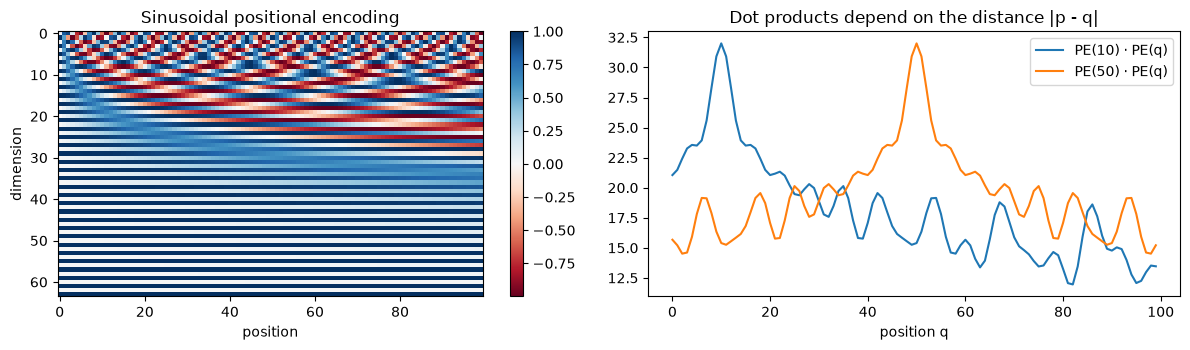

PE(p)·PE(p+5) for p = 10, 30, 70: [23.504, 23.504, 23.504] (equal: depends only on the offset)


In [8]:
perm = np.array([2, 0, 4, 1, 3])
Y_perm, _ = self_attention(X[perm])
print("self-attention without positions is permutation-equivariant:",
      np.allclose(Y_perm, Y[perm]))

def positional_encoding(n_pos, d):
    pos = np.arange(n_pos)[:, None]
    i = np.arange(d // 2)[None, :]
    angles = pos / (10000 ** (2 * i / d))
    pe = np.zeros((n_pos, d))
    pe[:, 0::2], pe[:, 1::2] = np.sin(angles), np.cos(angles)
    return pe

pe_small = positional_encoding(5, d_model)
Y_pos, _ = self_attention(X + pe_small)
Y_pos_perm, _ = self_attention(X[perm] + pe_small)
print("with positional encodings added, the same permutation changes the result:",
      not np.allclose(Y_pos_perm, Y_pos[perm]))

PE = positional_encoding(100, 64)
sim = PE @ PE.T
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
im = axes[0].imshow(PE.T, aspect="auto", cmap="RdBu"); axes[0].set(title="Sinusoidal positional encoding", xlabel="position", ylabel="dimension")
fig.colorbar(im, ax=axes[0])
for p in [10, 50]:
    axes[1].plot(sim[p], label=f"PE({p}) · PE(q)")
axes[1].set(title="Dot products depend on the distance |p - q|", xlabel="position q"); axes[1].legend()
fig.tight_layout(); fig.savefig(OUT / "positional_encoding.png", dpi=150); plt.show()
print("PE(p)·PE(p+5) for p = 10, 30, 70:", [round(float(sim[p, p + 5]), 3) for p in (10, 30, 70)], "(equal: depends only on the offset)")

- **Left:** the low dimensions oscillate quickly and the high dimensions slowly, so each position gets a unique pattern, like a set of clock hands.
- **Right:** $PE(p)\cdot PE(q)$ depends only on the **offset** $|p - q|$, which is why attention can learn relative positions.

GPT-2 and BERT use *learned* position embeddings instead (one trained vector per position, up to `max_positions`), but they play the same role.

### 2.6 Masked (causal) attention

A decoder that predicts token $t$ must not see tokens $t, t+1, \dots$, or training would be trivial copying. The **causal mask** sets the scores for $j > i$ to $-\infty$ before the softmax, so those weights become exactly 0 and each row renormalises over $j \le i$. The test below shows the consequence: changing a *future* token leaves every earlier output unchanged.

In [9]:
T = X.shape[0]
causal = np.tril(np.ones((T, T), dtype=bool))
Yc1, Wc1 = self_attention(X, causal)
print("causal weights:\n", Wc1.round(2))

X_changed = X.copy(); X_changed[-1] += 10.0             # change only the LAST token
Yc2, _ = self_attention(X_changed, causal)
print("outputs for positions 0..3 unchanged:", np.allclose(Yc1[:-1], Yc2[:-1]), "| position 4 changed:", not np.allclose(Yc1[-1], Yc2[-1]))

ref = F.scaled_dot_product_attention(*(torch.tensor(a)[None] for a in (X @ W_Q, X @ W_K, X @ W_V)), is_causal=True)[0].numpy()
print("matches PyTorch is_causal=True:", np.allclose(Yc1, ref))

causal weights:
 [[1.   0.   0.   0.   0.  ]
 [0.62 0.38 0.   0.   0.  ]
 [0.29 0.45 0.26 0.   0.  ]
 [0.22 0.06 0.18 0.54 0.  ]
 [0.37 0.17 0.25 0.12 0.1 ]]
outputs for positions 0..3 unchanged: True | position 4 changed: True
matches PyTorch is_causal=True: True


**All six concepts in one place:**

| Concept | Where Q comes from | Where K, V come from | Mask | Used in |
|---|---|---|---|---|
| Attention | any | any | optional | everything below |
| Self-attention | the sequence itself | the same sequence | none (encoder) | BERT, T5 encoder |
| Masked self-attention | the sequence so far | the same, positions $\le t$ | causal | GPT-2, T5 decoder |
| Cross-attention | decoder | encoder output | none | T5 / bert2bert decoder |
| Multi-head | $h$ projections of the above, run in parallel | | | all of them |
| Positional encoding | added to the input embeddings, so that order matters | | | all of them |

## 3. The same mechanisms inside real models

### 3.1 BERT self-attention: does "it" find "the animal"?

The sentence is *"The animal didn't cross the street because it was too tired."* For each of BERT-base's 144 heads (12 layers × 12 heads), we compare how much attention **"it"** pays to **"animal"** versus **"street"**.

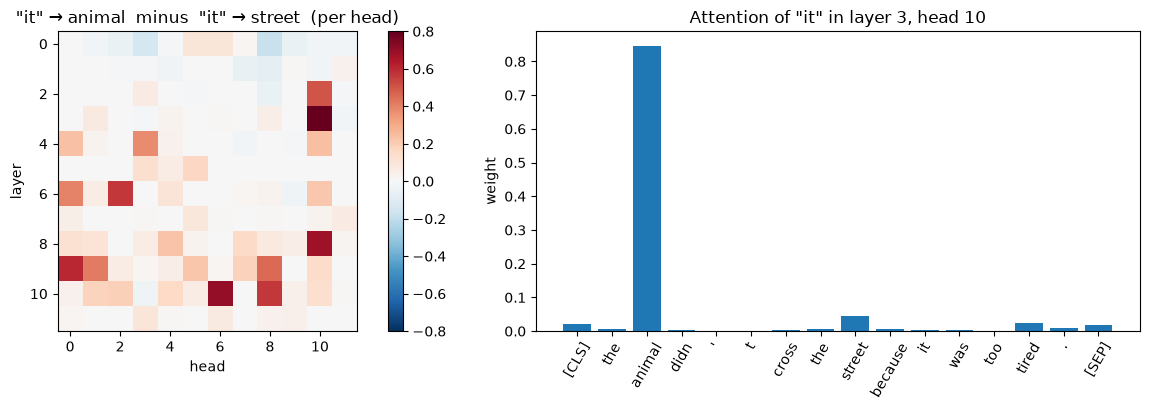

heads where 'it' attends more to 'animal' than to 'street': 93 / 144
strongest heads (animal, street, layer, head): [(np.float64(0.847), np.float64(0.046), 3, 10), (np.float64(0.714), np.float64(0.008), 10, 6), (np.float64(0.676), np.float64(0.0), 8, 10), (np.float64(0.608), np.float64(0.002), 9, 0), (np.float64(0.576), np.float64(0.009), 6, 2)]
rows sum to 1: [0.9999998211860657, 1.000000238418579]; max weight above the diagonal: 1.000 (BERT is bidirectional)


In [10]:
b = S["bert_attention"]
toks, it = b["tokens"], b["it_token_index"]
A_it = np.array(b["it_attention_by_layer_head"])                 # (layers, heads, tokens)
ia, ist = toks.index("animal"), toks.index("street")
diff = A_it[:, :, ia] - A_it[:, :, ist]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
im = axes[0].imshow(diff, cmap="RdBu_r", vmin=-0.8, vmax=0.8)
axes[0].set(title='"it" → animal  minus  "it" → street  (per head)', xlabel="head", ylabel="layer")
fig.colorbar(im, ax=axes[0])
L, H = np.unravel_index(diff.argmax(), diff.shape)
axes[1].bar(range(len(toks)), A_it[L, H]); axes[1].set_xticks(range(len(toks)), toks, rotation=60)
axes[1].set(title=f'Attention of "it" in layer {L}, head {H}', ylabel="weight")
fig.tight_layout(); fig.savefig(OUT / "bert_it_attention.png", dpi=150); plt.show()

print(f"heads where 'it' attends more to 'animal' than to 'street': {(diff > 0).sum()} / {diff.size}")
top = sorted(((A_it[l, h_, ia], A_it[l, h_, ist], l, h_) for l in range(diff.shape[0]) for h_ in range(diff.shape[1])), reverse=True)[:5]
print("strongest heads (animal, street, layer, head):", [(round(a, 3), round(s, 3), l, h_) for a, s, l, h_ in top])
print(f"rows sum to 1: {b['row_sums_min_max']}; max weight above the diagonal: {b['upper_triangle_max']:.3f} (BERT is bidirectional)")

In **93 of 144 heads**, "it" attends more to "animal" than to "street". A handful of heads, mostly in the middle and upper layers, resolve the pronoun almost completely: layer 3, head 10 puts **0.85** of the weight of "it" on "animal" and 0.05 on "street". Nobody told BERT about coreference. These heads emerged from masked-word prediction, because knowing what "it" refers to helps predict the missing words. The other heads do other jobs, so averaging over heads hides this, which is why heads are inspected individually.

Two other things are visible in the data:
- **BERT attends in both directions:** the maximum weight above the diagonal is 1.0.
- **A lot of attention goes to `[SEP]`** (a "no-op" or sink token; see the averaged map in Section 3.2).

### 3.2 GPT-2's causal mask, and attention sinks

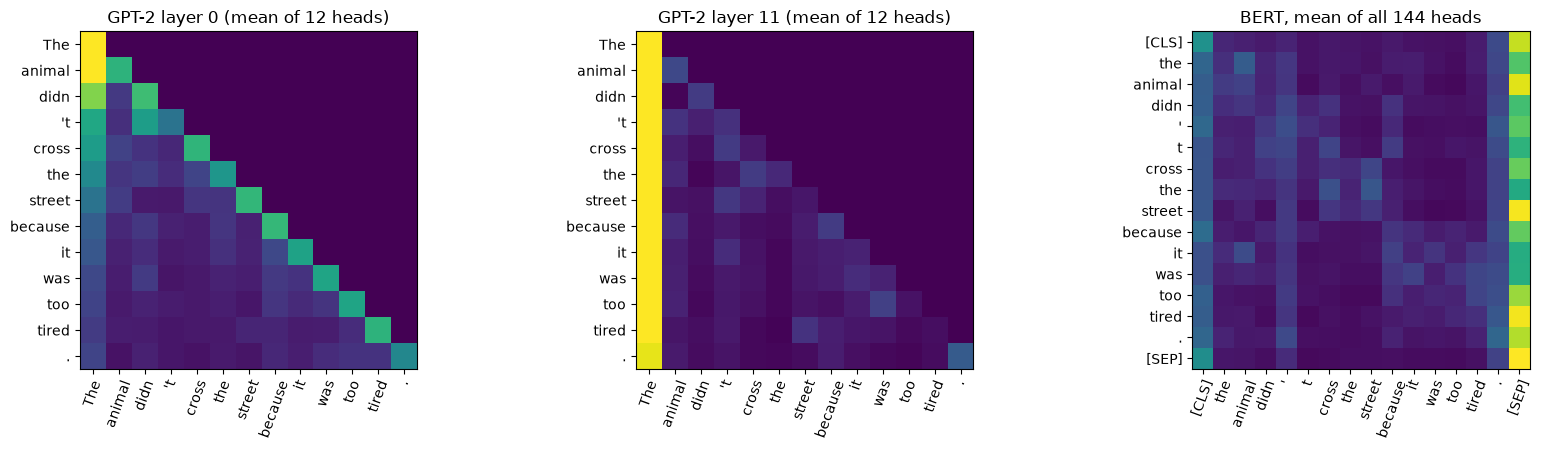

GPT-2 max weight above the diagonal (all layers, all heads): 0.0
GPT-2 last layer: mean weight on the FIRST token, from positions 1..12: 0.712
BERT: mean weight on [SEP]: 0.325


In [11]:
g = S["generation"]["causal_attention"]
gt = [t.replace("Ġ", "") for t in g["tokens"]]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
for ax, key, title in [(axes[0], "layer0_mean", "GPT-2 layer 0 (mean of 12 heads)"), (axes[1], "last_layer_mean", "GPT-2 layer 11 (mean of 12 heads)")]:
    ax.imshow(np.array(g[key]), cmap="viridis", vmin=0, vmax=0.6)
    ax.set_xticks(range(len(gt)), gt, rotation=70); ax.set_yticks(range(len(gt)), gt); ax.set_title(title)
bt = b["tokens"]
axes[2].imshow(np.array(b["all_layers_mean"]), cmap="viridis", vmin=0, vmax=0.4)
axes[2].set_xticks(range(len(bt)), bt, rotation=70); axes[2].set_yticks(range(len(bt)), bt); axes[2].set_title("BERT, mean of all 144 heads")
fig.tight_layout(); fig.savefig(OUT / "causal_vs_bidirectional_attention.png", dpi=150); plt.show()
last = np.array(g["last_layer_mean"])
print("GPT-2 max weight above the diagonal (all layers, all heads):", g["upper_triangle_max"])
print("GPT-2 last layer: mean weight on the FIRST token, from positions 1..12:", round(float(last[1:, 0].mean()), 3))
print("BERT: mean weight on [SEP]:", round(float(np.array(b["all_layers_mean"])[:, -1].mean()), 3))

- **The causal mask is exact:** GPT-2 puts **0.0** weight above the diagonal in every layer and head. That is the mask from Section 2.6, implemented in a real model. BERT (right) has no such triangle.
- **Attention sinks.** In GPT-2's last layer, every position sends on average **about 0.7** of its attention to the *first* token, "The". In BERT, about a third goes to `[SEP]`. These tokens act as a place to park attention when a head has nothing useful to read. It is a well-known property of trained Transformers, and it is a reason not to read attention maps as simple "importance" scores.

### 3.3 T5 cross-attention: soft alignment between German and English

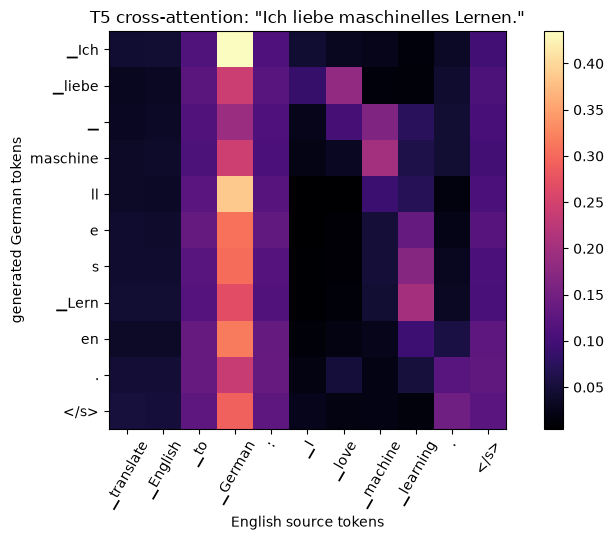

▁Ich       -> strongest content source token: ▁I         (0.045);  overall strongest: ▁German (0.435)
▁liebe     -> strongest content source token: ▁love      (0.183);  overall strongest: ▁German (0.242)
▁          -> strongest content source token: ▁machine   (0.164);  overall strongest: ▁German (0.191)
maschine   -> strongest content source token: ▁machine   (0.200);  overall strongest: ▁German (0.244)
ll         -> strongest content source token: ▁machine   (0.092);  overall strongest: ▁German (0.386)
e          -> strongest content source token: ▁learning  (0.135);  overall strongest: ▁German (0.309)
s          -> strongest content source token: ▁learning  (0.169);  overall strongest: ▁German (0.303)
▁Lern      -> strongest content source token: ▁learning  (0.202);  overall strongest: ▁German (0.270)
en         -> strongest content source token: ▁learning  (0.095);  overall strongest: ▁German (0.316)
.          -> strongest content source token: .          (0.122);  overall stronge

In [12]:
c = S["cross_attention"]
Wx = np.array(c["weights"])
fig, ax = plt.subplots(figsize=(8, 5.5))
im = ax.imshow(Wx, cmap="magma")
ax.set_xticks(range(len(c["source_tokens"])), c["source_tokens"], rotation=60)
ax.set_yticks(range(len(c["target_tokens"])), c["target_tokens"])
ax.set(title=f'T5 cross-attention: "{c["translation"]}"', xlabel="English source tokens", ylabel="generated German tokens")
fig.colorbar(im); fig.tight_layout(); fig.savefig(OUT / "t5_cross_attention.png", dpi=150); plt.show()

content = [i for i, t in enumerate(c["source_tokens"]) if t in ("▁I", "▁love", "▁machine", "▁learning", ".")]
for r, t in enumerate(c["target_tokens"]):
    j = max(content, key=lambda k: Wx[r, k])
    print(f"{t:<10} -> strongest content source token: {c['source_tokens'][j]:<10} ({Wx[r, j]:.3f});"
          f"  overall strongest: {c['source_tokens'][int(Wx[r].argmax())]} ({Wx[r].max():.3f})")

Among the *content* words, the alignment is exactly what a translator would draw:
- "liebe" → "love";
- the "maschine·ll·e·s" pieces → "machine", then "learning" (as "maschinelles" turns into "Lernen");
- "Lern" and "en" → "learning";
- "." → ".".

But the **largest** weight in every row goes to the task-prefix token "▁German", together with "to", ":" and "</s>". "Ich" puts only 0.045 on "I". Averaged over 12 layers × 12 heads, the prefix works as the task instruction the decoder keeps consulting, and as a sink. Cross-attention does carry alignment information, but a raw attention map is not a clean word-alignment table.

## 4. Hands-on 1: machine translation (encoder-decoder)

### 4.1 bert2bert (English → German): the lab's first cell

The lab calls the tokenizer with `add_special_tokens=False`. Each sentence was translated both with the lab's call and with default tokenisation, which adds `[CLS]` and `[SEP]`.

In [13]:
b2b = pd.DataFrame(S["translation_bert2bert"]["rows"])
b2b.pivot(index="input", columns="variant", values="output")

variant,default tokenisation,lab call (add_special_tokens=False)
input,,
I love machine learning.,i liebe maschinelles Lernen...,Ich liebe maschinelles Lernen.
Plants create energy through a process known as,"Pflanzen erzeugen Energie durch einen Prozess, der als Konservierung bekannt ist.",Pflanzen erzeugen Energie durch einen so genannten Prozess.
Plants create energy through a process known as photosynthesis.,"Pflanzen Pflanzen erzeugen Energie durch einen Prozess, der als Photosynthese bekannt ist...","Pflanzen erzeugen Energie durch einen Prozess, der Photosynthese genannt wird."
She sat on the bank of the river and watched the boats.,she saß am Ufer des Flusses und beobachtete die Boote..,Sie saß am Ufer des Flusses und beobachtete die Boote.
The meeting has been postponed until next Thursday.,die Sitzung wurde auf den nächsten Donnerstag verschoben.,die Sitzung wurde auf den nächsten Donnerstag verschoben.
"The weather is nice today, so we are going for a walk.","die Wetter ist schön heute, so dass wir einen Spaziergang machen..","das Wetter ist heute schön, also gehen wir spazieren."


**Findings:**
- **The lab's `add_special_tokens=False` is the right call for this model.** It is what the model card specifies, and it gives clean German: "Ich liebe maschinelles Lernen.", "Sie saß am Ufer des Flusses und beobachtete die Boote.". Only the lowercase sentence starts ("das Wetter", "die Sitzung") are slightly off.
- **Default tokenisation is visibly worse** with the same model and the same sentences:
  - a repeated word ("Pflanzen **Pflanzen**");
  - lowercase "**i** liebe";
  - the wrong article, "**die** Wetter" (it should be *das*);
  - trailing "..".

  A tokenisation convention is part of the model's interface, just as the CPT column order was in Week 6.
- **The lab's own input is an incomplete sentence** ("…a process known as"). With the lab's call the model smooths over the gap: "…durch einen **so genannten** Prozess" ("by a *so-called* process"). With default tokenisation it **invents** the missing word: "…der als **Konservierung** bekannt ist" ("known as *conservation*"). The lab notebook's "Translated text" was a sentence the model had partly made up.
- **The bank sentence is disambiguated correctly:** "bank of the river" → "Ufer" (riverbank), not "Bank" (the financial institution).

### 4.2 T5-base: one model, many tasks, chosen by a text prefix

In [14]:
t5 = pd.DataFrame(S["translation_t5"]["rows"])
display(t5.pivot(index="input", columns="target", values="output"))
print("the lab's exact call (cache_implementation='static', max_length=30):", S["translation_t5"]["lab_call"])
print("\nprefixes for languages T5 was NOT trained on:")
for r in S["translation_t5"]["unsupported_targets"]:
    print(f"  'translate English to {r['target']}: I love machine learning.' -> {r['output']!r}")

target,French,German,Romanian
input,,,
I love machine learning.,J'aime l'apprentissage par machine.,Ich liebe maschinelles Lernen.,Iubesc învățarea automată.
"Let's go have some wine, cause thats how we shine","Allons en déguster un peu de vin, car c'est ainsi que nous brillons","Lassen Sie uns einen Wein trinken, denn so leuchten wir","Să ne dăm vinul, pentru că astfel strălucim"
Plants create energy through a process known as photosynthesis.,Les plantes créent de l'énergie par un processus connu sous le nom de photosynthèse.,"Die Pflanzen erzeugen Energie durch einen Prozess, der als Photosynthese bekannt ist.",Utilităţile creează energie printr-un proces cunoscut drept fotosinteză.
She sat on the bank of the river and watched the boats.,Elle s'est assise sur la rive de la rivière et a surveillé les bateaux.,Sie saß am Ufer des Flusses und beobachtete die Boote.,Ea stătea pe malul râului şi privea ambarcaţiunile.
The meeting has been postponed until next Thursday.,La réunion a été reportée à jeudi prochain.,Die Sitzung wurde auf den kommenden Donnerstag verschoben.,Întâlnirea a fost amânată până joia viitoare.
"The weather is nice today, so we are going for a walk.","Le temps est agréable aujourd'hui, donc nous allons faire une promenade.","Das Wetter ist heutzutage nett, so dass wir einen Spaziergang machen.","Vremea este frumoasă astăzi, așa că mergem la plimbare."


the lab's exact call (cache_implementation='static', max_length=30): {'output': "Allons en déguster un peu de vin, car c'est ainsi que nous brillons", 'output_tokens': 27}

prefixes for languages T5 was NOT trained on:
  'translate English to Spanish: I love machine learning.' -> 'Ich liebe maschinelles Lernen.'
  'translate English to Hindi: I love machine learning.' -> 'Hindi Ich liebe maschinelles Lernen.'


- **Mostly fluent and correct in all three languages.** The lab's wine sentence reproduces the lab notebook's output *exactly* ("Allons en déguster un peu de vin, car c'est ainsi que nous brillons", 27 tokens, within `max_length=30`).
- **Word-sense errors:**
  - in Romanian, "Plants" became "**Utilităţile**", i.e. *utilities*, as in power *plants*;
  - "I love machine learning" became "l'apprentissage **par machine**" in French, instead of the standard "apprentissage automatique";
  - "today" became "**heutzutage**" ("nowadays") in German.
- **T5's languages are fixed by its training data.** It was trained on English→German, French and Romanian only. For "translate English to **Spanish**" it outputs **German**, and for **Hindi** it outputs "Hindi Ich liebe…". The prefix is just text: the model maps an unfamiliar instruction onto the closest task it knows, and never says it cannot do the task.

### 4.3 English → Hinglish (fine-tuned Flan-T5)

In [15]:
pd.DataFrame(S["translation_hinglish"]["rows"])

,input,output
0,life is crazy. Not me,Life crazy haiNot me
1,I am going to the market tomorrow.,Mai kal market jaaraha hu.
2,This movie was really boring.,Ye movie bohot boring tha.
3,Can you help me with my homework?,Kya aap muje mera homework help karsakte hai?


The model reproduces the lab notebook's odd output *exactly*: "life is crazy. Not me" → "**Life crazy haiNot me**". It drops "is" into the Hindi copula "hai", fails to split the sentence, and misses a space. The ordinary sentences come out as natural Hinglish ("Ye movie bohot boring tha.", "Mai kal market jaaraha hu."). The first sentence is informal, fragmentary English, unlike the fine-tuning data.

## 5. Hands-on 2: encoder-only models

### 5.1 Sentiment analysis (DistilBERT, the lab's default pipeline model)

In [16]:
sent = pd.DataFrame(S["sentiment"]["rows"])
sent["correct"] = np.where(sent.expected.isin(["MIXED", "NEUTRAL"]), "n/a (no such label)",
                           np.where(sent.label == sent.expected, "✓", "✗"))
display(sent[["category", "text", "expected", "label", "score", "correct"]])
clear = sent[~sent.expected.isin(["MIXED", "NEUTRAL"])]
print(f"accuracy on the {len(clear)} probes with a definite answer: {(clear.label == clear.expected).mean():.0%}")
print(f"mean confidence when wrong: {clear[clear.label != clear.expected].score.mean():.3f}")

,category,text,expected,label,score,correct
0,lab,I'd want to kick you and ensure that you are hurt,NEGATIVE,NEGATIVE,0.97421,✓
1,clear positive,This is the best course I have ever taken.,POSITIVE,POSITIVE,0.99981,✓
2,clear negative,The lecture was boring and far too long.,NEGATIVE,NEGATIVE,0.99975,✓
3,negation,The movie was not bad at all.,POSITIVE,POSITIVE,0.99799,✓
4,negation,I don't think this phone is worth the money.,NEGATIVE,NEGATIVE,0.99980,✓
5,double negation,It's not that I didn't enjoy it.,POSITIVE,NEGATIVE,0.99872,✗
6,sarcasm,"Oh great, another Monday. I just love being stuck in traffic for two hours.",NEGATIVE,POSITIVE,0.98162,✗
7,sarcasm,"Wow, the battery lasted a whole twenty minutes. Impressive.",NEGATIVE,POSITIVE,0.99768,✗
8,mixed,The food was excellent but the service was painfully slow.,MIXED,NEGATIVE,0.99879,n/a (no such label)
9,neutral,The train leaves at 5 pm from platform 3.,NEUTRAL,NEGATIVE,0.91837,n/a (no such label)


accuracy on the 11 probes with a definite answer: 64%
mean confidence when wrong: 0.994


- **Right on the clear cases:** the lab's sentence (NEGATIVE, 0.974), clear praise and criticism, simple negation ("not bad at all" → POSITIVE, 0.998), and informal text.
- **Wrong on 4 of 11 definite cases, and confidently so** (mean confidence 0.99 when wrong):
  - **double negation:** "It's not that I didn't enjoy it" → NEGATIVE;
  - **both sarcasm probes** → POSITIVE, at 0.98 and 0.998. The words "great", "love" and "impressive" win;
  - **domain shift:** "The tumour shrank significantly" → NEGATIVE, 0.999. "Tumour" reads as negative, although shrinking is good news.
- **No neutral or mixed label.** The model was fine-tuned on SST-2, which has two classes, so neutral facts ("The train leaves at 5 pm") are forced to NEGATIVE or POSITIVE with over 90% confidence. The score is the confidence of a two-way classifier, not calibrated evidence.

In Part 2, *all eight* LLMs classify the sarcastic sentence correctly as NEGATIVE. A 67M-parameter encoder fine-tuned on movie-review sentiment and a 7B+ chat model are different tools: the encoder is cheap, fast and deterministic, but it only knows its training distribution.

### 5.2 Semantic search: meaning vs keywords (MiniLM sentence embeddings)

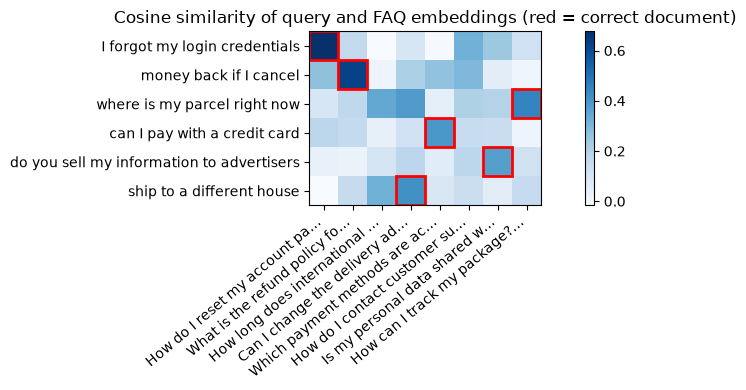

semantic search correct: 6 / 6
keyword matching correct: 0 / 6 (no query shares a content word with its document)


In [17]:
ss = S["semantic_search"]
docs = ss["documents"]
M = np.array([r["semantic_scores"] for r in ss["rows"]])
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(M, cmap="Blues"); fig.colorbar(im)
ax.set_xticks(range(len(docs)), [d[:28] + "…" for d in docs], rotation=40, ha="right")
ax.set_yticks(range(len(ss["rows"])), [r["query"] for r in ss["rows"]])
for i, r in enumerate(ss["rows"]):
    ax.add_patch(plt.Rectangle((r["gold"] - .5, i - .5), 1, 1, fill=False, ec="red", lw=2))
ax.set_title("Cosine similarity of query and FAQ embeddings (red = correct document)")
fig.tight_layout(); fig.savefig(OUT / "semantic_search.png", dpi=150); plt.show()
print("semantic search correct:", sum(r["semantic_top"] == r["gold"] for r in ss["rows"]), "/", len(ss["rows"]))
print("keyword matching correct:", sum(r["keyword_top"] == r["gold"] for r in ss["rows"]), "/", len(ss["rows"]),
      "(no query shares a content word with its document)")

**The embeddings find the right FAQ for all 6 queries.** For example:
- "I forgot my login credentials" → "reset my account password", 0.68;
- "money back if I cancel" → "refund policy for cancelled orders", 0.63.

The queries were written deliberately with *no shared keywords*, so keyword matching finds nothing at all. This is the notes' first encoder-only use case, "search based on **meaning**, rather than just matching exact words". It is also the retrieval step of every RAG system. The margins are sometimes narrow: "where is my parcel right now" scores 0.45 for tracking and 0.38 for change of address. A real system would add reranking, or a threshold that allows "no good match".

### 5.3 Masked-word prediction: bidirectional context (BERT)

In [18]:
for r in S["fill_mask"]["rows"]:
    print(f"{r['sentence']:<45} " + ", ".join(f"{w} ({p:.2f})" for w, p in r["top5"]))

The capital of France is [MASK].              paris (0.42), lille (0.07), lyon (0.06), marseille (0.04), tours (0.03)
The [MASK] barked at the mailman.             man (0.15), dog (0.14), driver (0.07), guard (0.06), woman (0.04)
I went to the bank to deposit [MASK] money.   the (0.57), some (0.36), my (0.04), his (0.01), her (0.01)
I went to the [MASK] to deposit money.        bank (0.87), store (0.02), office (0.01), library (0.01), vault (0.00)
She sat on the bank of the [MASK].            river (0.37), creek (0.10), stream (0.08), lake (0.06), pool (0.05)


BERT uses the words on **both sides** of the gap:
- "I went to the [MASK] to deposit money." → **bank** (0.87). The clue ("deposit money") comes *after* the gap, where a left-to-right decoder could not see it.
- "She sat on the bank of the [MASK]." → **river** (0.37), creek, stream, lake. BERT reads "bank" in its river sense because of "sat on the…".
- "The capital of France is [MASK]." → **paris** (0.42), then other French cities.

That is what "encoder-only models understand and represent existing text" means in practice.

## 6. Hands-on 3: GPT-style generation (decoder-only)

### 6.1 The lab's exact call

In [19]:
gen = S["generation"]
lab = gen["lab_call"]
print(lab["call"])
print(f"-> {lab['total_tokens']} tokens generated (asked for max_length=30)\n")
print(lab["output"][:600], "…")

generator("The future of AI is", max_length=30, num_return_sequences=1)
-> 261 tokens generated (asked for max_length=30)

The future of AI is uncertain, but the company is eager to see what its AI could accomplish in the future.

"We're excited to have a very good product in our hands," said Dave C. Smith, chief of the company's AI division. "We're very excited to have a very good product in our hands."

Machine learning is already being used in scientific research and engineering to improve understanding of complex biological structures. That means that it could be used to better understand how organisms develop and develop, and will help them adapt to an environment in which they are most vulnerable to disease. …


**`max_length=30` was silently ignored.** The `text-generation` pipeline adds its own default of `max_new_tokens=256` (GPT-2's model config sets no length, as recorded above), and transformers 5 gives `max_new_tokens` precedence over `max_length`. The lab notebook's own warning said so: *"Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set."* The call produced **261 tokens**, several paragraphs, including an invented quotation from a made-up "Dave C. Smith". Using `max_new_tokens` explicitly (Section 6.2) avoids this.

### 6.2 Decoding strategies: the same model, different text

In [20]:
for s in gen["strategies"]:
    print(f"=== {s['strategy']}  {s['settings']}")
    for o in s["outputs"]:
        print("   ", o.replace("\n", " ")[:230])
    print()

=== greedy  {'do_sample': False}
    The future of AI is uncertain. The future of AI is uncertain.  The future of AI is uncertain. The future of AI is uncertain.  The future of AI is uncertain. The future of AI is uncertain

=== beam search (5 beams)  {'do_sample': False, 'num_beams': 5, 'early_stopping': True}
    The future of AI is in the hands of the next generation of scientists and engineers.  The future of AI is in the hands of the next generation of scientists and engineers.  The future of AI is in the

=== beam search + no_repeat_ngram_size=3  {'do_sample': False, 'num_beams': 5, 'no_repeat_ngram_size': 3}
    The future of AI is in the hands of the next generation of scientists and engineers.  In the next few years, we will see the emergence of a new type of artificial intelligence that will be able to solve complex problems

=== sampling T=0.7, top-k 50  {'do_sample': True, 'temperature': 0.7, 'top_k': 50}
    The future of AI is uncertain, but the company is eager to see wh

The distribution $P(x_t \mid x_{<t})$ is the same in every case. Only the **decoding rule** changes:

| Strategy | What it does | What happened |
|---|---|---|
| **Greedy** | always takes the argmax | loops: "The future of AI is uncertain." repeats until the length limit. Over 120 tokens it never escapes the cycle (the same failure as the Week 8 bigram greedy decoder). |
| **Beam search** (5 beams) | keeps the 5 most probable partial sequences | fluent, but still repeats a whole sentence |
| **Beam + `no_repeat_ngram_size=3`** | forbids any repeated 3-gram | fluent, no loop; the standard fix |
| **Sampling, T = 0.7** | samples from the sharpened distribution | varied, coherent, on topic |
| **Sampling, T = 1.0** | samples from the model's own distribution | more varied, drifts to invented specifics ("In September 2014, the company announced…") |
| **Sampling, T = 1.5** | samples from the flattened distribution | loses coherence ("Deep State was one example") |
| **Nucleus, top-p = 0.9** | samples only from the smallest set with 90% of the probability mass | varied, mostly coherent |

With the same seeds, all the sampling strategies start with the same words ("uncertain, but the company is eager…"). The random draws are shared, and only how sharply they select changes.

### 6.3 What the decoder actually computes: next-token distributions

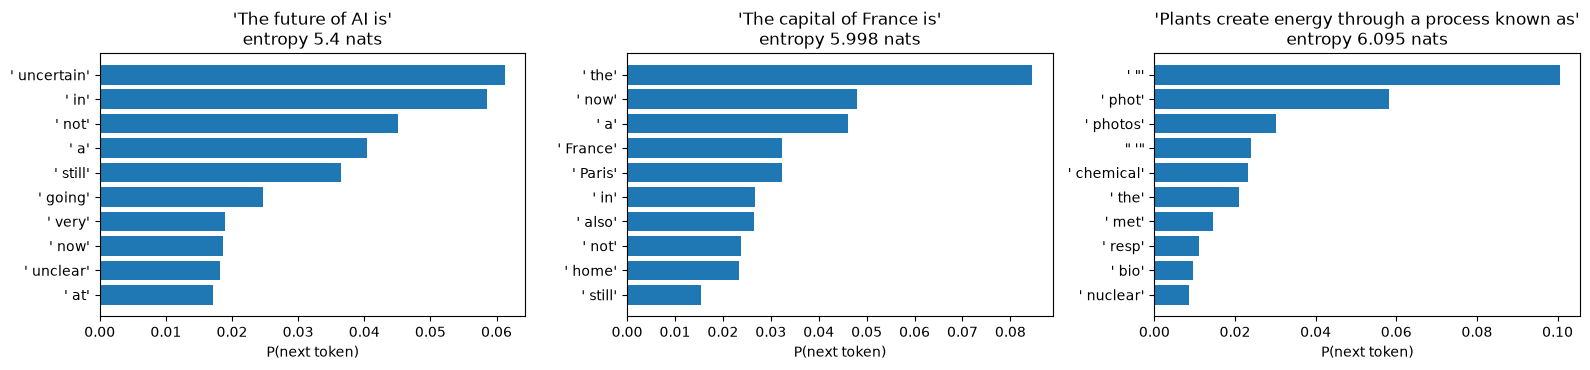

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
for ax, n in zip(axes, gen["next_token"]):
    words, probs = zip(*n["top10"])
    ax.barh([repr(w) for w in words][::-1], list(probs)[::-1])
    ax.set(title=f"{n['prompt']!r}\nentropy {n['entropy_nats']} nats", xlabel="P(next token)")
fig.tight_layout(); fig.savefig(OUT / "gpt2_next_token.png", dpi=150); plt.show()

**GPT-2 models text, not facts:**
- **After "The capital of France is",** " Paris" is only **5th** (3.2%), behind " the", " now", " a" and " France". Web text continues that phrase in many ways, and GPT-2 (124M parameters, no instruction tuning) predicts continuations, not answers.
- **The entropies are about 5.4–6.1 nats,** so the probability mass is spread over hundreds of tokens.
- **After "…a process known as",** the top guess is an opening quote (10%), then " phot" (the start of "photosynthesis", split into sub-word pieces).

This is exactly the Week 8 picture, $P(\text{next token} \mid \text{previous tokens})$, with the table replaced by a 12-layer network. Instruction-tuned chat models (Part 2) answer the question instead, because further training reshaped the same kind of distribution.

## 7. Summary: what each architecture is for, as shown by these experiments

| | Encoder-decoder | Encoder-only | Decoder-only |
|---|---|---|---|
| Attention | encoder self-attention, masked decoder self-attention, **cross-attention** | bidirectional self-attention | **causal** self-attention |
| Evidence here | cross-attention aligns *liebe* ↔ *love*; bert2bert and T5 translate well | "it" → "animal" heads; *bank* resolved from later context; 6/6 semantic search | exact zero weight on future tokens; next-token distributions |
| Strength | sequence → sequence (translation) | understanding, classification, retrieval | open-ended generation |
| Failure seen | invented endings for incomplete input; word-sense errors; silent fallback to German | sarcasm, double negation, domain shift; forced into two labels | greedy loops; ignored length argument; fluent invention |

The lab's closing point, "predict the next token", links this lab to Week 8. Part 2 takes the decoder-only family to chat-model scale.